In [ ]:
betas = 1, 2, 3, 4
c3 = 2.9, 3.2, 3.3, 3.3
ca = 2.4, 2.8,.. 
cb = 2.5, 2.8, , 3
cc = 3.3, 3.4, 3.5, 3.7
p  = 4.9, 5, 5, 4.6 


# Code trying a set of beta choices for duration models before large simulations

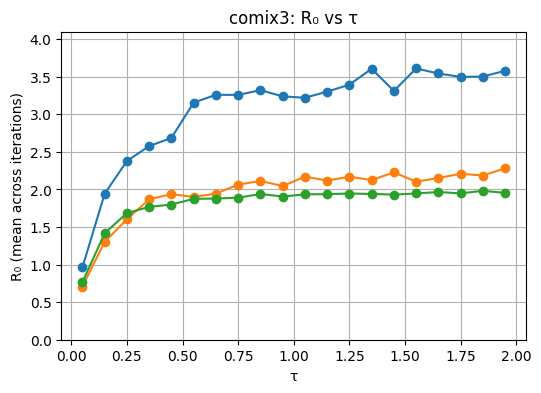

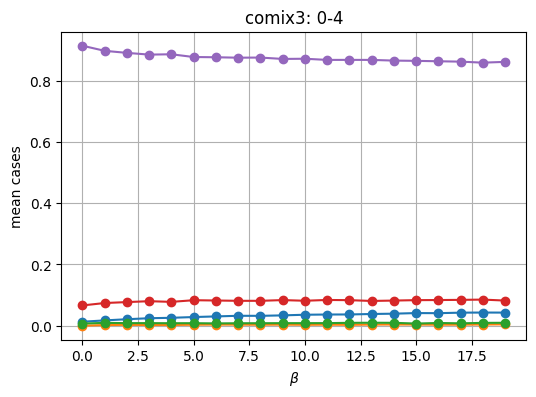

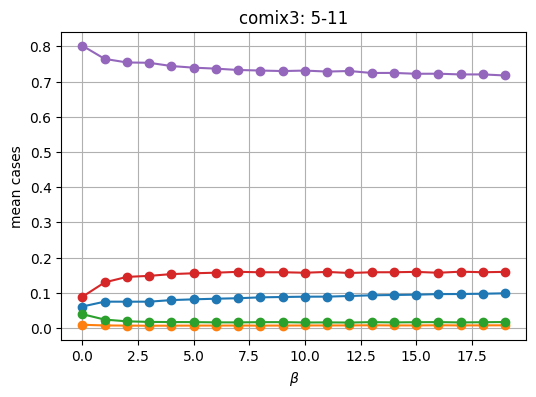

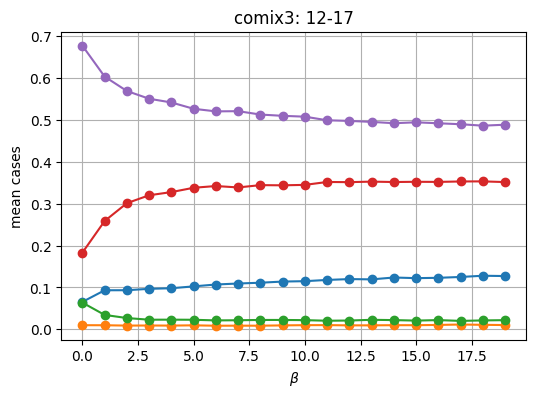

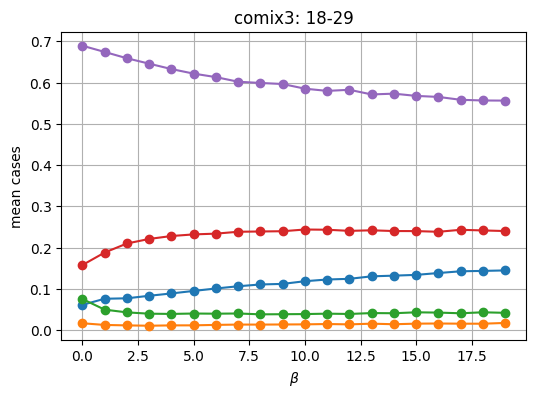

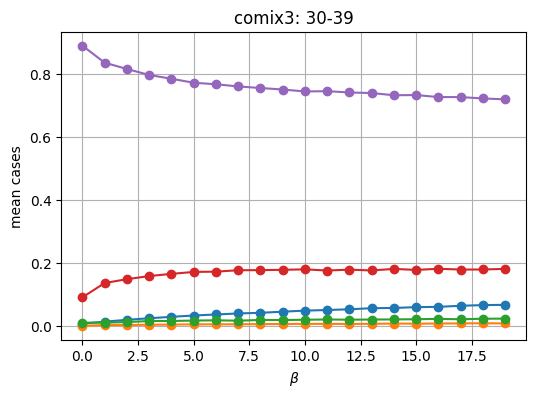

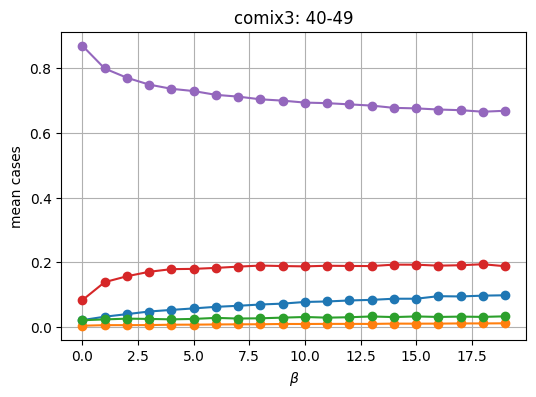

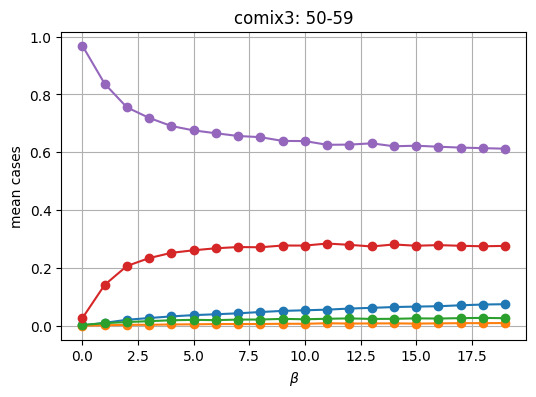

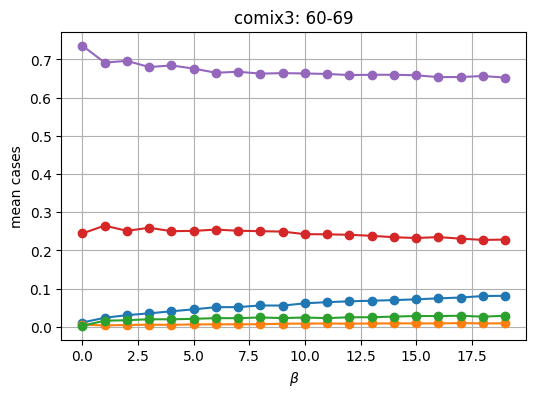

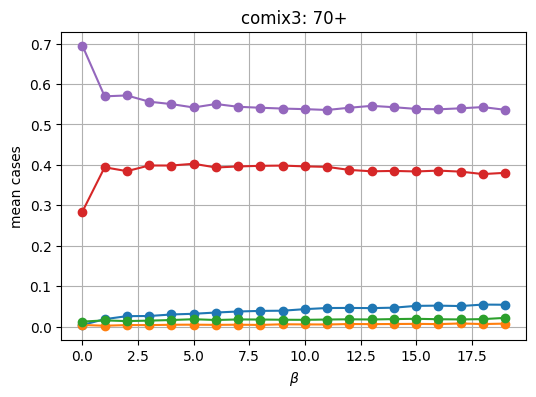

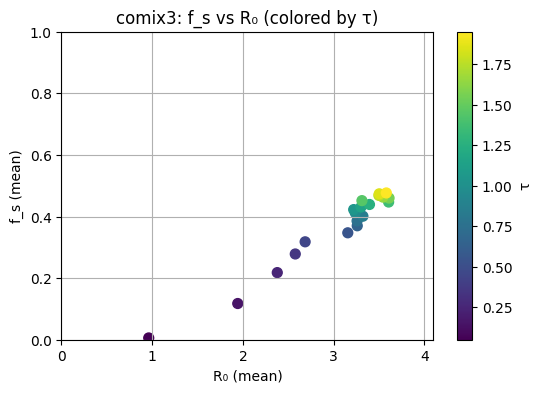

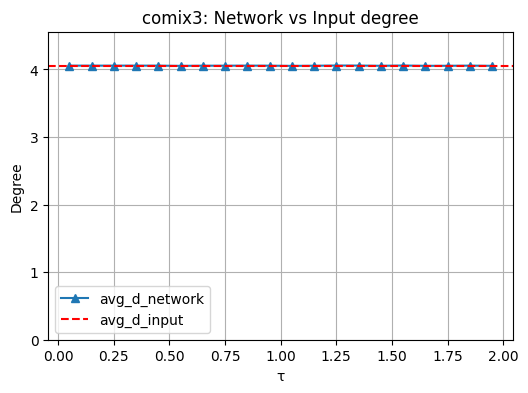

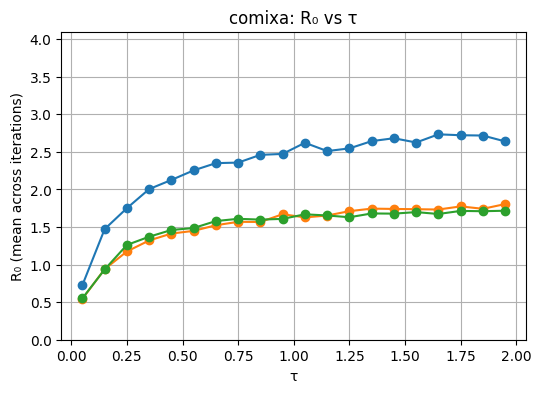

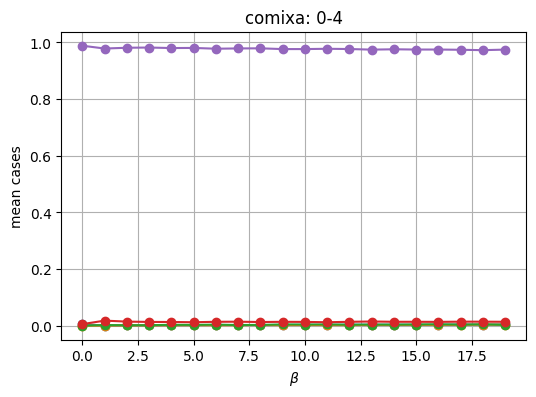

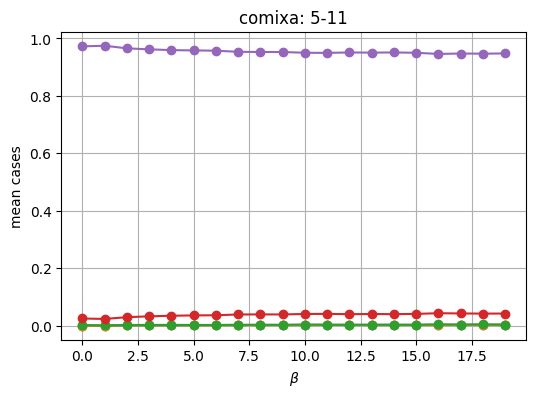

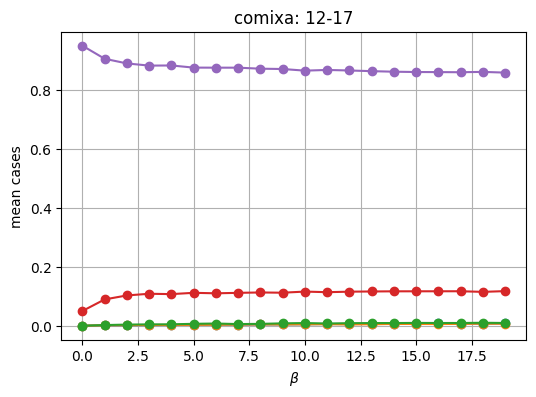

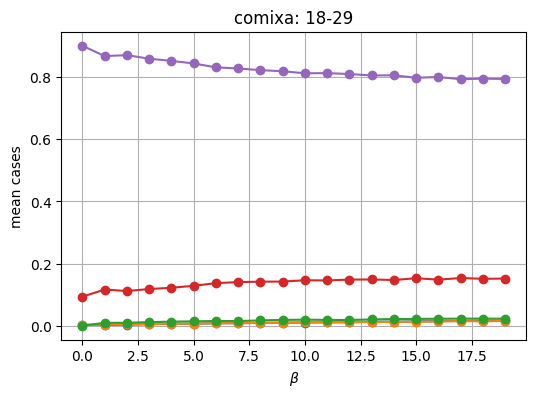

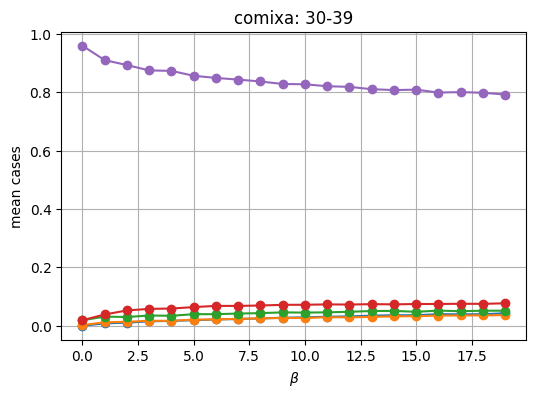

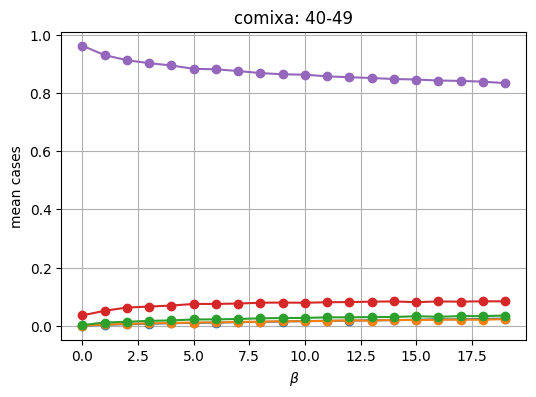

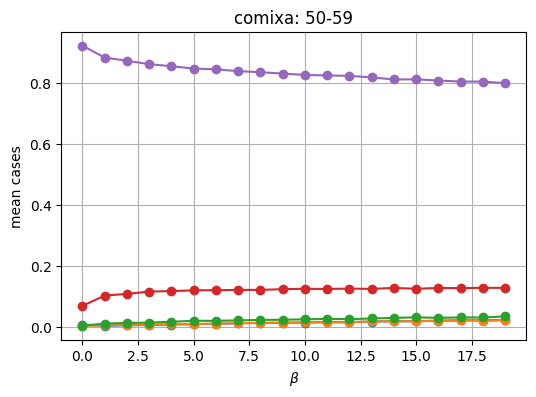

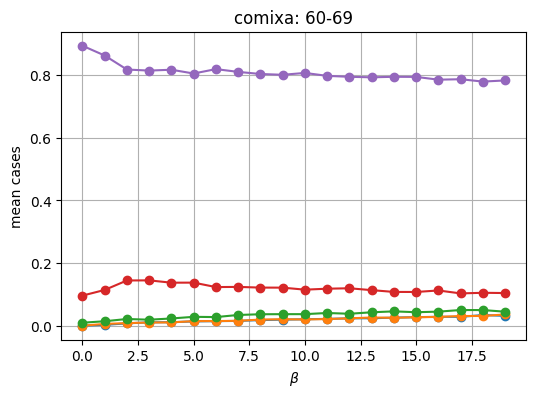

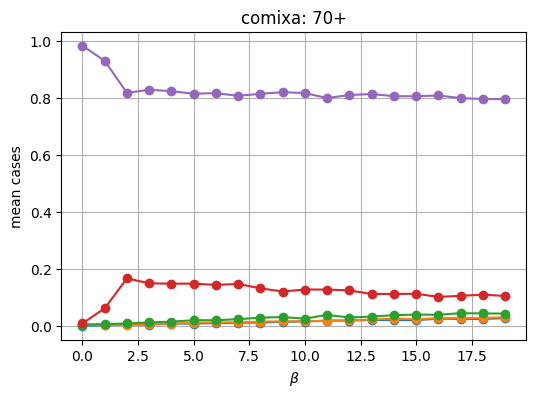

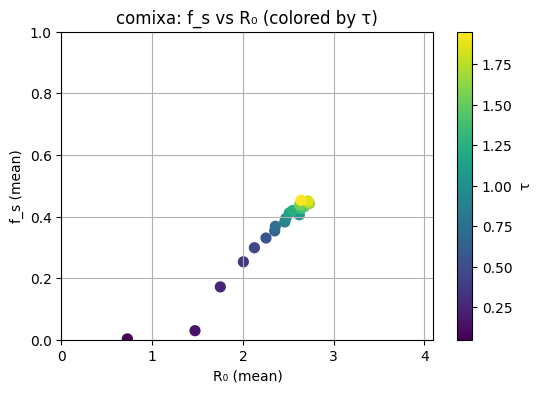

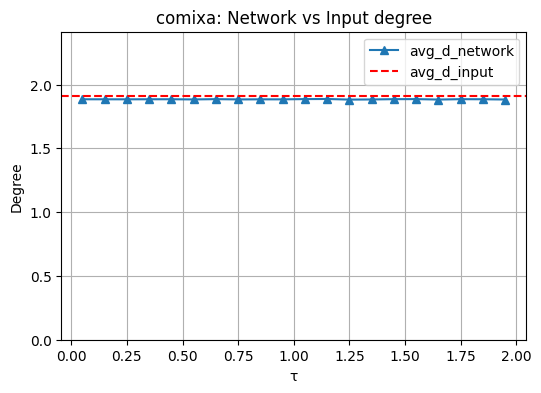

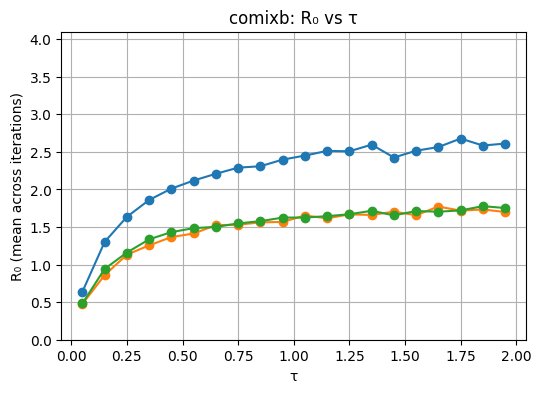

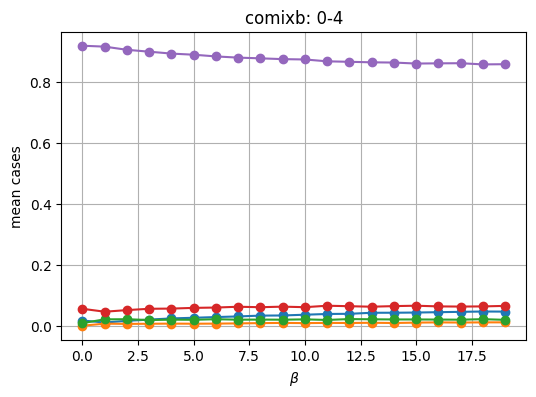

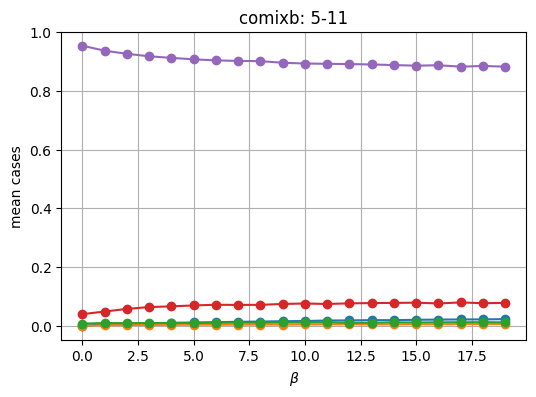

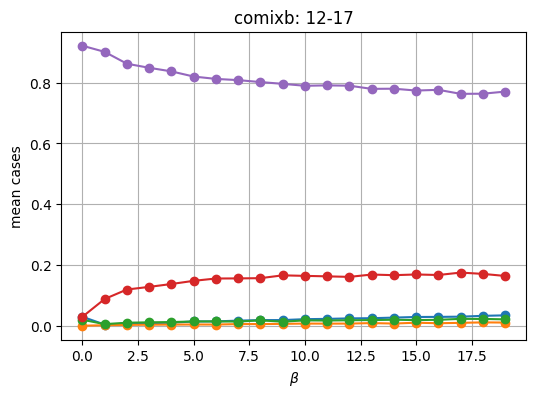

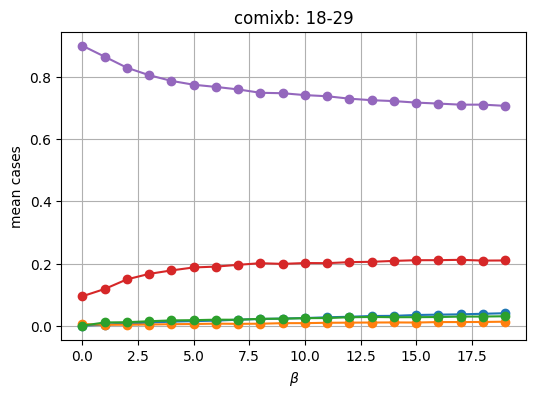

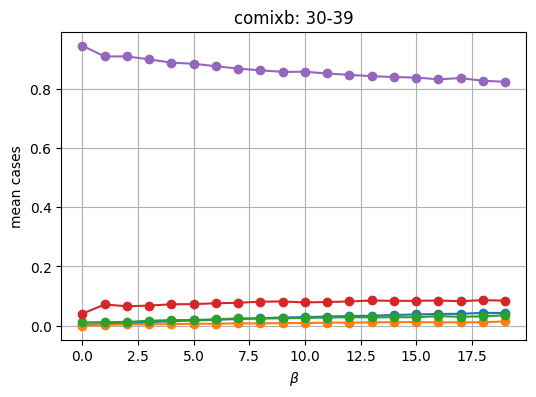

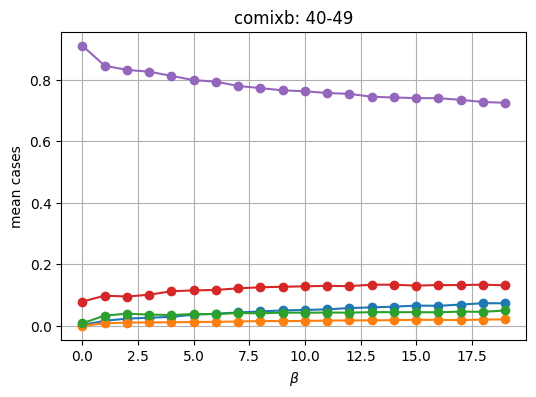

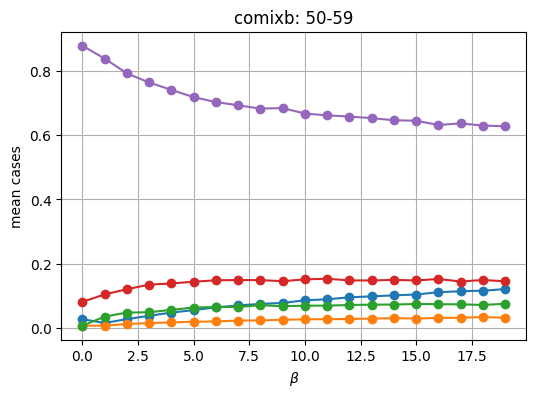

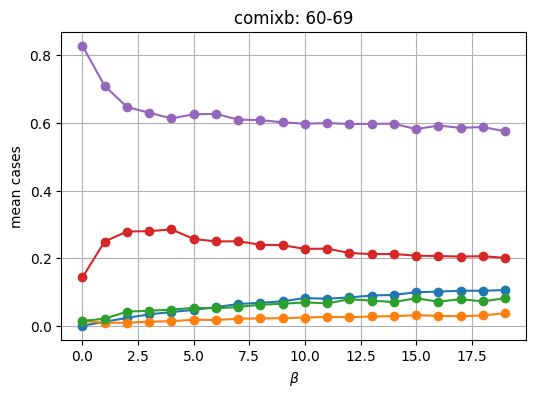

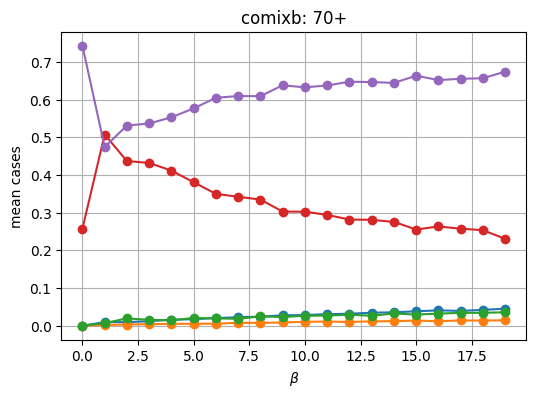

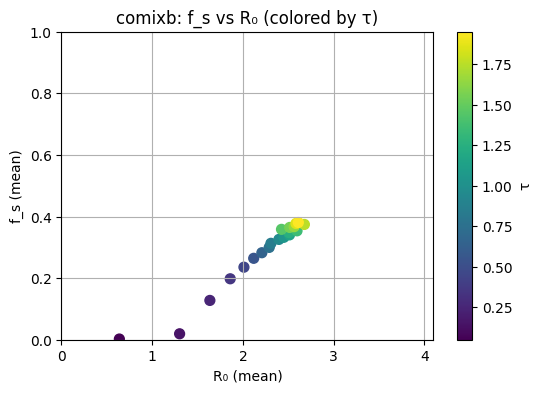

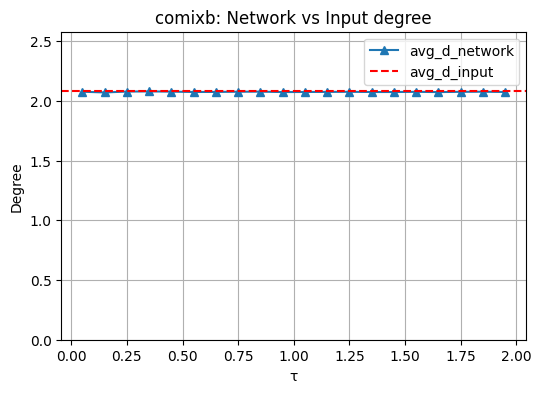

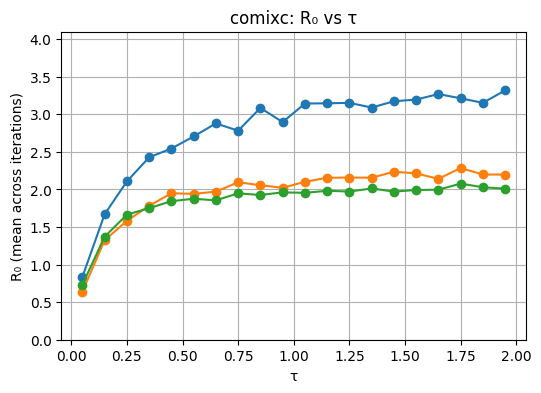

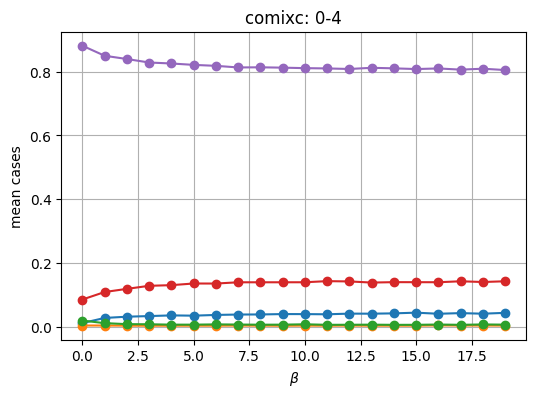

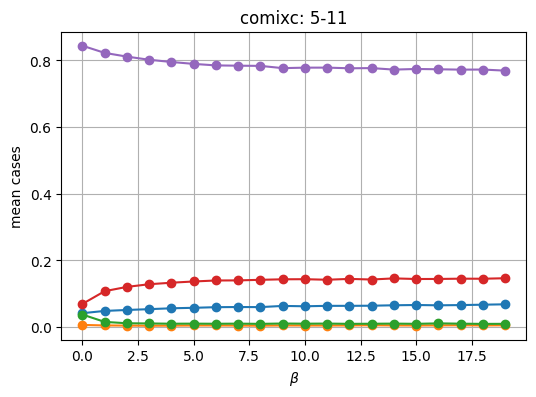

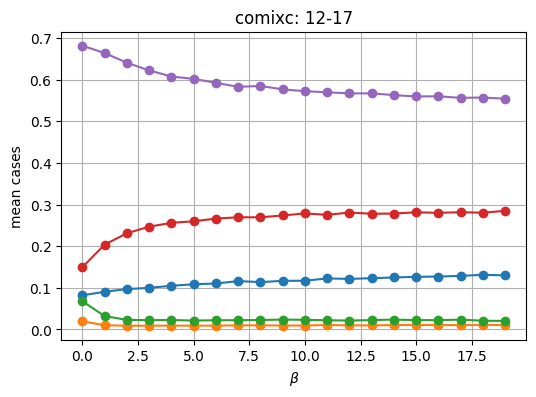

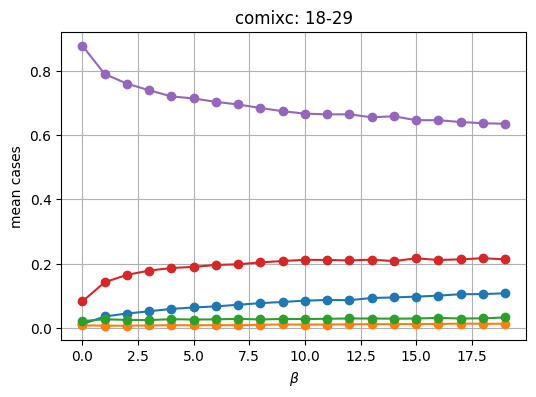

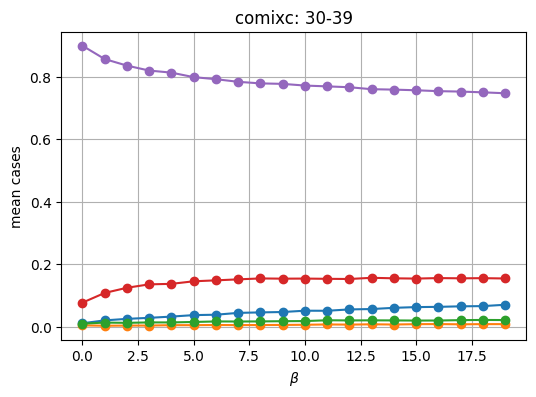

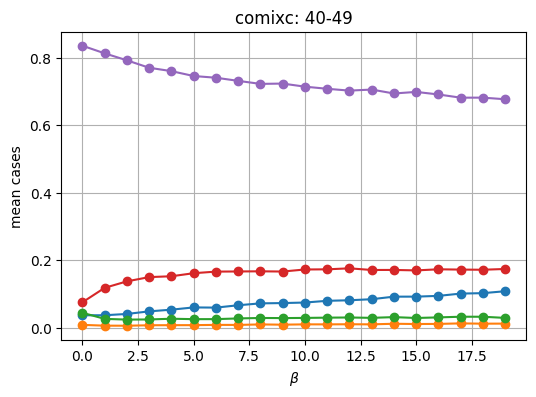

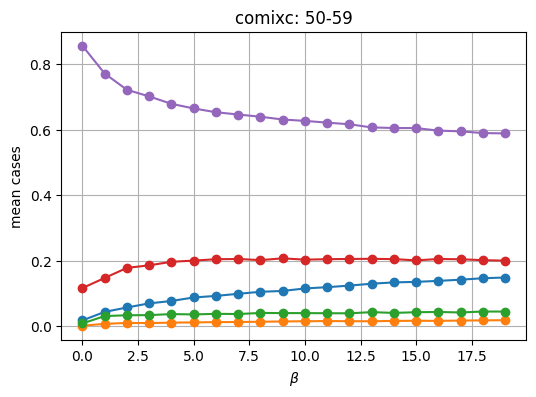

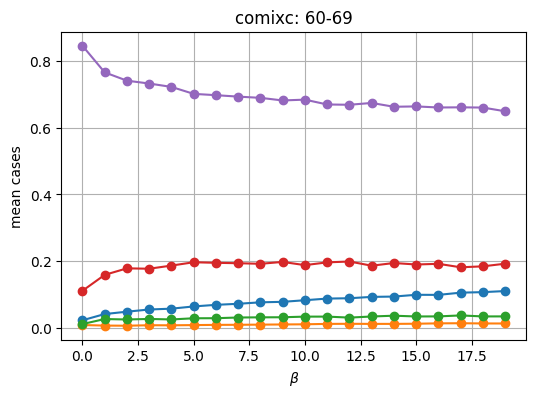

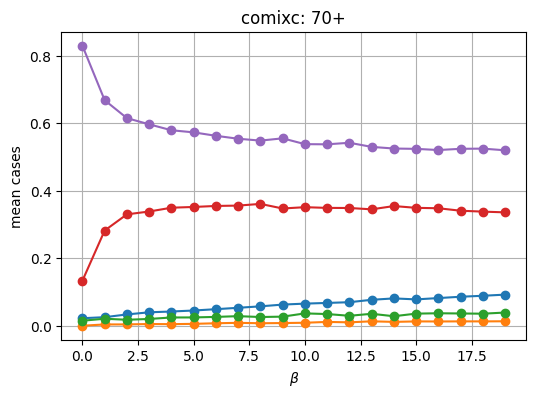

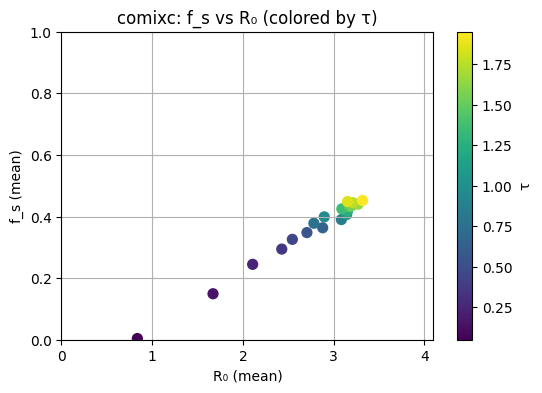

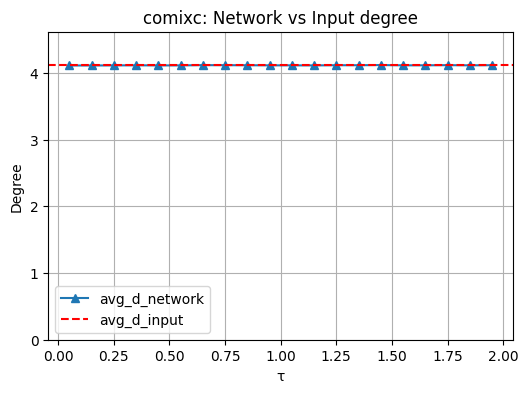

FileNotFoundError: [Errno 2] No such file or directory: 'sims/poly_20.json'

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import json

datas = ['comix3','comixa','comixb','comixc','poly']
n=100_000

bucket_labels = ['0-4', '5-11', '12-17', '18-29', '30-39', '40-49', '50-59', '60-69', '70+']
duration_labels = ['0-5 mins', '5-15 mins', '15-60 mins', '1-4 hours', '4+ hours']

for data in datas:
    with open(f'sims/{data}_20.json', 'r') as f:
        res = json.load(f)

    # Extract from your dictionary
    taus = np.array(res["taus"])
    r0 = np.array(res["r0"])           
    r02 = np.array(res["r02"])           
    r03 = np.array(res["r03"])           
    fs = np.array(res["fs"])           # shape (len(taus), iterations)
    tmp = res["age_dur_sc"]
    avg_d_network = np.array(res["avg_d_network"])
    avg_d_input = res["avg_d_input"]/n   # scalar

    # Average across iterations
    r0_mean = [np.mean([b for b in a if b>0]) for a in r0]
    r02_mean = [np.mean([b for b in a if b>0]) for a in r02]
    r03_mean = [np.mean([b for b in a if b>0]) for a in r03]
    fs_mean = [np.mean([b for b in a if b>0]) for a in fs]
    tmp_a = {}
    for i, t in enumerate(taus):
        tmp_a[t] = np.array([b for b in tmp[i] if len(b)>0])
    keys = list(tmp_a.keys())
    keys.sort()
    dur_breakdown = []
    for key in keys:
        dur_breakdown.append(np.mean([[sum(b) for b in a] for a in tmp_a[key]], axis=0))

    # 1) R0 vs taus
    plt.figure(figsize=(6,4))
    plt.plot(taus, r0_mean, marker='o')
    plt.plot(taus, r02_mean, marker='o')
    plt.plot(taus, r03_mean, marker='o')
    plt.xlabel("τ")
    plt.ylabel("R₀ (mean across iterations)")
    plt.title(f"{data}: R₀ vs τ")
    plt.ylim(0, 4.1)
    plt.grid(True)
    plt.show()
    
    new_age = np.zeros((9, 5, len(dur_breakdown)))
    for i, _ in enumerate(dur_breakdown):
        for j in range(9):
            for k in range(5):
                new_age[j][k][i] = dur_breakdown[i][j][k]
    for age, tmp in enumerate(new_age):
        plt.figure(figsize=(6,4))
        for j in range(5):
            plt.plot(range(len(tmp[j])), [a/sum([b[idx] for b in tmp]) for idx, a in enumerate(tmp[j])], marker='o', label=f"{duration_labels[j]}")
        plt.xlabel(r"$\beta$")
        plt.ylabel("mean cases")
        plt.title(f"{data}: {bucket_labels[age]}")
        # plt.ylim(0, 4.1)
        # plt.legend()
        plt.grid(True)
        plt.show()
        plt.close()

    # 3) fs vs R0
    plt.figure(figsize=(6,4))
    plt.scatter(r0_mean, fs_mean, c=taus, cmap="viridis", s=50)
    plt.colorbar(label="τ")
    plt.xlabel("R₀ (mean)")
    plt.ylabel("f_s (mean)")
    plt.title(f"{data}: f_s vs R₀ (colored by τ)")
    plt.xlim(0, 4.1)
    plt.ylim(0, 1)
    plt.grid(True)
    plt.show()

    # 4) avg_d_network vs avg_d_input
    plt.figure(figsize=(6,4))
    plt.plot(taus, avg_d_network, marker='^', label="avg_d_network")
    plt.axhline(y=avg_d_input, color='red', linestyle='--', label="avg_d_input")
    plt.xlabel("τ")
    plt.ylabel("Degree")
    plt.title(f"{data}: Network vs Input degree")
    plt.ylim(0, max(max(avg_d_network), avg_d_input) + .5)
    plt.legend()
    plt.grid(True)
    plt.show()
